# (01) Cadena: fit P-VAE

device = ```cuda:1```

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from mcfe.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

In [3]:
from mcfe.main.load_model import load_model
from mcfe.common.helpers import print_num_params

## Load model

In [4]:
## Raw

### Linear encoders
wandb_run_id = 'pal-lab/MCFE/g0g3d8r3'  # sigmoid, 0.5 --> FEV: 0.249
# wandb_run_id = 'pal-lab/MCFE/ekb7sh92'  # sigmoid, 0.05 --> FEV: 0.204
# wandb_run_id = 'pal-lab/MCFE/dadjjx0a'  # cubic, 0.5 --> FEV: 0.200
# wandb_run_id = 'pal-lab/MCFE/6toq9cls'  # cubic, 0.05 --> FEV: 0.185

## Whitened

### Linear encoders
# wandb_run_id = 'pal-lab/MCFE/zlff603m'  # wht, sigmoid, 0.5  -->  FEV: 0.262
# wandb_run_id = 'pal-lab/MCFE/ujkyj574'  # wht, sigmoid, 0.05 --> FEV: 0.112
# wandb_run_id = 'pal-lab/MCFE/6ubciwud' # wht, cubic, 0.5  -->  FEV: 0.224

### Nonlinear encoders
# wandb_run_id = 'pal-lab/MCFE/xrro8wt3'  # wht, sigmoid, 0.5  -->  FEV: 0.094
# wandb_run_id = 'pal-lab/MCFE/8jndsrvh'  # wht, sigmoid, 0.05  -->  FEV: 0.105


tr, meta = load_model(target_path=wandb_run_id, verbose=True)

Path 'pal-lab/MCFE/g0g3d8r3' matches WandB format. Fetching config...

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


# params: 53.1 K

Successfully loaded model from 
/home/hadi/Projects/MCFE/checkpoints/pois-sigmoid_prob_ImageNet40_kms-(256,11,3)/b(300)-ep(30)-lr(0.001)_beta(1)_te
mp(1→0.5)/2026_03_29,17:58

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_29,19:58).pt

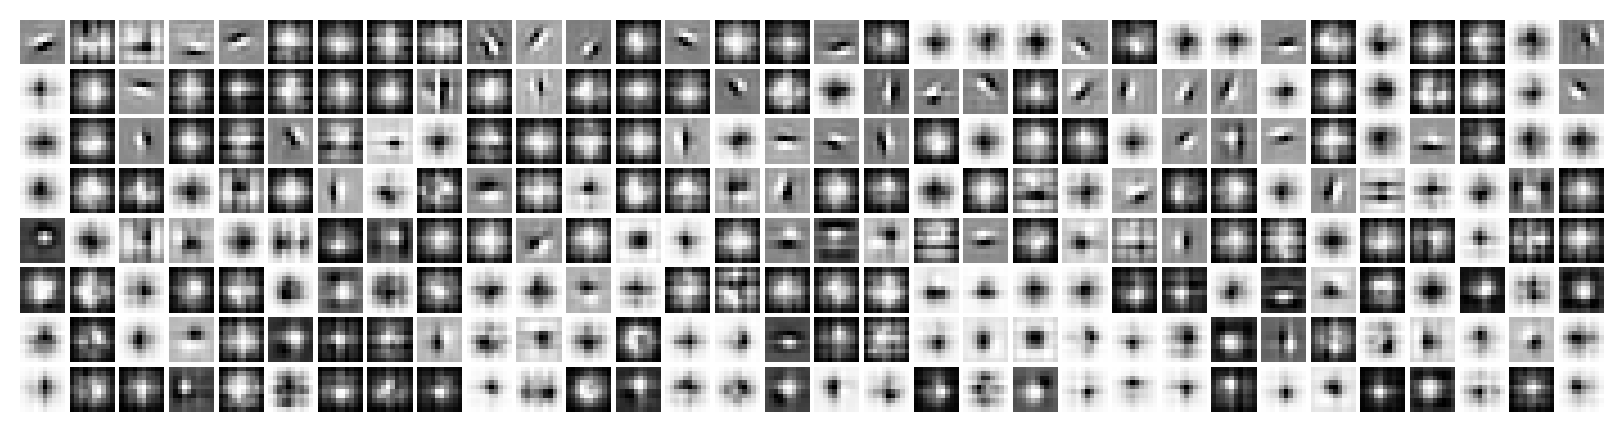

In [5]:
tr.model.show();

In [6]:
msg = f"{tr.model.cfg.dataset},\t EAT_{tr.model.cfg.indicator_approx},\t temp_stop = {tr.cfg.temp_stop}"
print(msg)

ImageNet40,      EAT_sigmoid,    temp_stop = 0.5

In [7]:
print_num_params(tr.model)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|  PoissonVAE |   53.1 K   |
|     ———     |    ———     |
|     dec     |   25.6 K   |
|     enc     |   25.6 K   |
|    u_init   |    256     |
+-------------+------------+

In [9]:
print(tr.model.enc)

Conv2d(1, 256, kernel_size=(10, 10), stride=(3, 3), bias=False)

## Cadena fit

In [8]:
import importlib

spec = importlib.util.spec_from_file_location(
    'normative_modules', '/home/hadi/Dropbox/git/_CadenaV1/normative.py')
normative_modules = importlib.util.module_from_spec(spec)
sys.modules['normative_modules'] = normative_modules
spec.loader.exec_module(normative_modules)

In [9]:
train_ds_raw, val_ds_raw = normative_modules.get_train_val_datasets()

In [10]:
kws = dict(model=tr.model, batch_size=300, device=device, feature='firing-rate')

train_ds_feat = normative_modules.extract_features(dataset=train_ds_raw, **kws)
val_ds_feat = normative_modules.extract_features(dataset=val_ds_raw, **kws)

In [11]:
train_dl, val_dl = normative_modules.build_dataloaders(
    train_ds_feat.to(device), val_ds_feat.to(device), batch_size=1000)

In [12]:
num_neurons = train_ds_feat[0]['robs'].shape[0]

readout_model = normative_modules.ReadoutOnly(
    filter_dims=tr.model.cfg.latent_sz,
    num_neurons=num_neurons,
    rank=2,
).to(device)

optimizer = torch.optim.AdamW(
    readout_model.parameters(),
    lr=1e-3,
    weight_decay=0.1,
)

In [13]:
%%time


best_state, train_losses, val_losses = normative_modules.fit_readout_sgd(
    readout_model, train_dl, val_dl, optimizer,
    max_epochs=1_000, patience=20, min_lr=1e-4,
)
readout_model.load_state_dict(best_state)

/home/hadi/Dropbox/git/_CadenaV1/normative.py:271: RuntimeWarning: Degrees of freedom <= 0 for slice.
  obs_var = torch.nanmean(torch.tensor(np.nanvar(resp_n.numpy(), axis=0, ddof=1)))


Epoch 0, lr: 0.000021, Validation Loss: 5574.5498046875
New best model
Epoch 10, lr: 0.000221, Validation Loss: 834.7476196289062
New best model
Epoch 20, lr: 0.000421, Validation Loss: 2.175027847290039
New best model
Epoch 30, lr: 0.000620, Validation Loss: 0.11554144322872162
New best model
Epoch 40, lr: 0.000820, Validation Loss: 0.0028642858378589153
New best model
Epoch 50, lr: 0.001000, Validation Loss: 0.0005274262512102723
New best model
Epoch 60, lr: 0.001000, Validation Loss: 2.382233333264594e-06
New best model
Epoch 70, lr: 0.000999, Validation Loss: -0.0004077679477632046
Epoch 80, lr: 0.000998, Validation Loss: -0.0011836508056148887
New best model
Epoch 90, lr: 0.000996, Validation Loss: -0.0018935106927528977
New best model
Epoch 100, lr: 0.000994, Validation Loss: -0.0028041198384016752
New best model
Epoch 110, lr: 0.000991, Validation Loss: -0.004097615834325552
New best model
Epoch 120, lr: 0.000988, Validation Loss: -0.006034242920577526
New best model
Epoch 130, 

<All keys matched successfully>

Held-out FEV mean: 0.22356989979743958

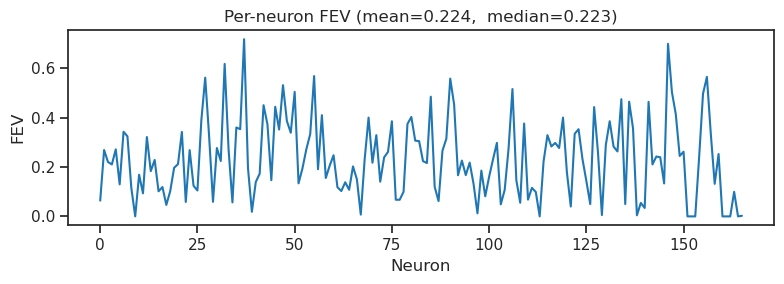

In [14]:
eval_results = normative_modules.run_eval(readout_model, val_dl)
fev, var_explained, explainable_var, mse, total_variance = eval_results
fev_mean = torch.nanmean(fev).item()
fev_all = torch.nan_to_num(fev.detach().cpu(), nan=0.0).clip(min=0)


print('Held-out FEV mean:', fev_mean)

plt.figure(figsize=(8, 3))
plt.plot(fev_all)
plt.title(f'Per-neuron FEV (mean={fev_mean:.3f},  median={np.nanmedian(fev_all):0.3f})')
plt.xlabel('Neuron')
plt.ylabel('FEV')
plt.tight_layout()
plt.show()

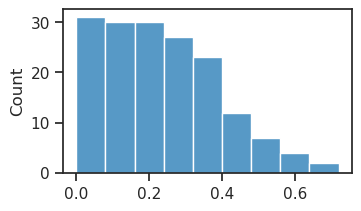

In [15]:
fig, ax = create_figure(1, 1, (3.5, 2))
sns.histplot(fev_all, ax=ax)
plt.show()

## make random model

In [3]:
from mcfe.main.model import MODEL_CLASSES
from mcfe.main.config_model import CFG_CLASSES
from mcfe.train.train import Trainer, ConfigTrain

from mcfe.default_cfgs import default_configs

In [4]:
model_type = 'pois'

cfg_vae, cfg_tr = default_configs(dataset='vH16-wht', model_type=model_type)

cfg_vae['latent_channels'] = 256
cfg_vae['latent_pixels'] = 10
cfg_vae['latent_stride'] = 3
cfg_vae['lin_enc'] = False

cfg = CFG_CLASSES[model_type](**cfg_vae)
cfg.input_sz = [1, 40, 40]  # mock construct

model = MODEL_CLASSES[model_type](cfg)
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

In [5]:
print(tr.model.cfg.latent_sz)

(256, 10, 10)

In [6]:
print(tr.model.dec)

ConvDictionary(in_channels=256, out_channels=1, kernel_size=13, stride=3)

In [7]:
print(tr.model.enc)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): SiLU(inplace=True)
  (2): ResBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=64, out_features=4, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=4, out_features=64, bias=True)
        (3): Sigmoid()
      )
    )
    (skip): FactorizedReduce(
      (act): SiLU()
      (convs): ModuleList(
        (0-3): 4 x Conv2d(32, 16, kernel_size=(1, 1), stride=(2, 2))
      )
    )
  )
  (3): ResBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=8, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=8, out_features=128, bias=True)
        (3): Sigmoid()
      )
    )
    (skip): FactorizedReduce(
      (act): SiLU()
      (convs): ModuleList(
        (0-3): 4 x Conv2d(64, 32, kernel_size=(1, 1), stride=(2, 2))
      )
    )
  )
  (4): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1))
)

In [8]:
x = torch.randn((123, 1, 40, 40)).to(device)
out = tr.model(x)
lamb = out['posterior'].rate

lamb.shape

torch.Size([123, 256, 10, 10])

## normative files

In [9]:
import importlib

spec = importlib.util.spec_from_file_location(
    'normative_modules', '/home/hadi/Dropbox/git/_CadenaV1/normative.py')
normative_modules = importlib.util.module_from_spec(spec)
sys.modules['normative_modules'] = normative_modules
spec.loader.exec_module(normative_modules)

In [10]:
train_ds_raw, val_ds_raw = normative_modules.get_train_val_datasets()

In [11]:
kws = dict(model=tr.model, batch_size=1024, device=device, log_rate=False)

train_ds_feat = normative_modules.extract_features(dataset=train_ds_raw, **kws)
val_ds_feat = normative_modules.extract_features(dataset=val_ds_raw, **kws)

In [12]:
train_dl, val_dl = normative_modules.build_dataloaders(
    train_ds_feat.to(device), val_ds_feat.to(device), batch_size=256)

In [13]:
num_neurons = train_ds_feat[0]['robs'].shape[0]

readout_model = normative_modules.ReadoutOnly(
    filter_dims=tr.model.cfg.latent_sz,
    num_neurons=num_neurons,
    rank=2,
).to(device)

In [14]:
optimizer = torch.optim.AdamW(readout_model.parameters(), lr=1e-3, weight_decay=0.1)

best_state, train_losses, val_losses = normative_modules.fit_readout_sgd(
    readout_model, train_dl, val_dl, optimizer,
    max_epochs=100, patience=20, min_lr=1e-3,
)
readout_model.load_state_dict(best_state)

/home/hadi/Dropbox/git/_CadenaV1/normative.py:246: RuntimeWarning: Degrees of freedom <= 0 for slice.
  obs_var = torch.nanmean(torch.tensor(np.nanvar(resp_n.numpy(), axis=0, ddof=1)))


Epoch 0, lr: 0.000201, Validation Loss: 5.39398193359375
New best model
Epoch 1, lr: 0.000401, Validation Loss: 2.6543543338775635
New best model
Epoch 2, lr: 0.000600, Validation Loss: 1.2101563215255737
New best model
Epoch 3, lr: 0.000800, Validation Loss: 0.7684622406959534
New best model
Epoch 4, lr: 0.001000, Validation Loss: 0.5959029793739319
New best model
Epoch 5, lr: 0.001000, Validation Loss: 0.34548306465148926
New best model
Epoch 6, lr: 0.001000, Validation Loss: 0.07607466727495193
New best model
Epoch 7, lr: 0.001000, Validation Loss: 0.0072450279258191586
New best model
Epoch 8, lr: 0.001000, Validation Loss: 0.0022762594744563103
New best model
Epoch 9, lr: 0.001000, Validation Loss: 0.002292536897584796
Epoch 10, lr: 0.001000, Validation Loss: 0.0017424533143639565
New best model
Epoch 11, lr: 0.001000, Validation Loss: 0.0018730208976194263
Epoch 12, lr: 0.001000, Validation Loss: 0.0015123136108741164
New best model
Epoch 13, lr: 0.001000, Validation Loss: 0.00243

<All keys matched successfully>

Held-out FEV mean: -0.0015123136108741164

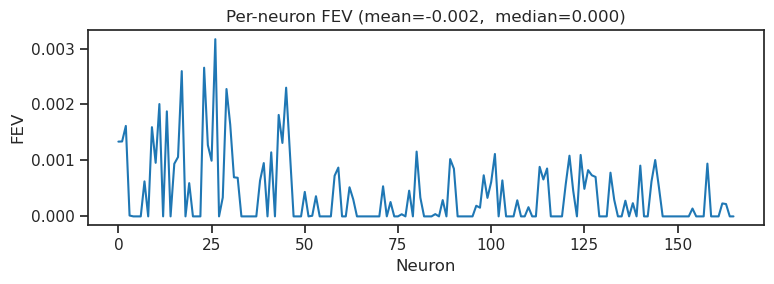

In [15]:
eval_results = normative_modules.run_eval(readout_model, val_dl)
fev, var_explained, explainable_var, mse, total_variance = eval_results
fev_mean = torch.nanmean(fev).item()
fev_all = torch.nan_to_num(fev.detach().cpu(), nan=0.0).clip(min=0)


print('Held-out FEV mean:', fev_mean)

plt.figure(figsize=(8, 3))
plt.plot(fev_all)
plt.title(f'Per-neuron FEV (mean={fev_mean:.3f},  median={np.nanmedian(fev_all):0.3f})')
plt.xlabel('Neuron')
plt.ylabel('FEV')
plt.tight_layout()
plt.show()

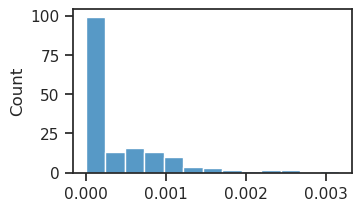

In [16]:
fig, ax = create_figure(1, 1, (3.5, 2))
sns.histplot(fev_all, ax=ax)
plt.show()

In [21]:
train_ds_raw[0]['stim'].shape

torch.Size([1, 40, 40])

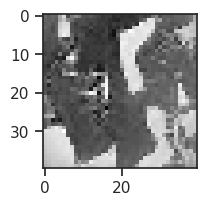

In [35]:
imshow(train_ds_raw[10]['stim'][0], cmap='Grays_r')
plt.show()

In [38]:
x = tonp(train_ds_raw[:]['stim'])
x.shape

(18560, 1, 40, 40)

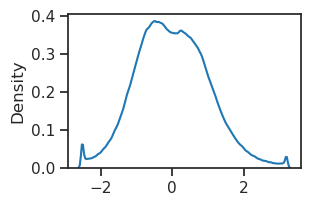

In [45]:
sns.kdeplot(x.ravel())
plt.show()